# Chapter 1: Introduction to Linear Algebra for Machine Learning

**Book:** *Linear Algebra with Applications in Machine Learning: From Intuitive Understanding to Python Coding*

---

This notebook accompanies Chapter 1, which sets the stage for the entire book. The chapter is primarily conceptual, so this notebook focuses on:

1. Illustrating the distinction between linear and non-linear functions
2. Demonstrating the core Python libraries used throughout the book
3. Providing hands-on exercises that connect introductory ideas to ML practice

By the end of this notebook, you should have a working Python environment and an intuitive sense of why linear algebra is the computational backbone of modern machine learning.

## 1.1 Setup: Importing Libraries

Throughout this book, we rely on a consistent set of Python libraries. Let us import them here and verify that everything is installed correctly. If any import fails, install the missing package via `pip install <package-name>`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import sympy as sp
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# For cleaner plots in the notebook
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print(f"NumPy version:  {np.__version__}")
print(f"SciPy version:  {la.__name__} (from scipy {__import__('scipy').__version__})")
print(f"SymPy version:  {sp.__version__}")
print("All imports successful.")

NumPy version:  1.26.4
SciPy version:  scipy.linalg (from scipy 1.13.1)
SymPy version:  1.13.2
All imports successful.


## 1.2 Linear vs. Non-Linear Functions

A function $f$ is **linear** if it satisfies two properties for all inputs $\mathbf{x}_1, \mathbf{x}_2$ and any scalar $c$:

$$f(\mathbf{x}_1 + \mathbf{x}_2) = f(\mathbf{x}_1) + f(\mathbf{x}_2) \quad \text{(additivity)}$$

$$f(c\,\mathbf{x}) = c\,f(\mathbf{x}) \quad \text{(homogeneity)}$$

Geometrically, a linear function of one variable produces a straight line through the origin. In ML, affine functions of the form $f(\mathbf{x}) = W\mathbf{x} + \mathbf{b}$ (which include a bias term) are the building blocks of neural network layers. Strictly speaking, these are affine rather than linear, but the weight multiplication $W\mathbf{x}$ is the linear component that linear algebra governs.

Non-linear functions introduce curvature. Activation functions like ReLU, sigmoid, and tanh are non-linear, and it is precisely this non-linearity that gives neural networks their expressive power. Without it, stacking layers would reduce to a single linear transformation.

Let us visualize both types.

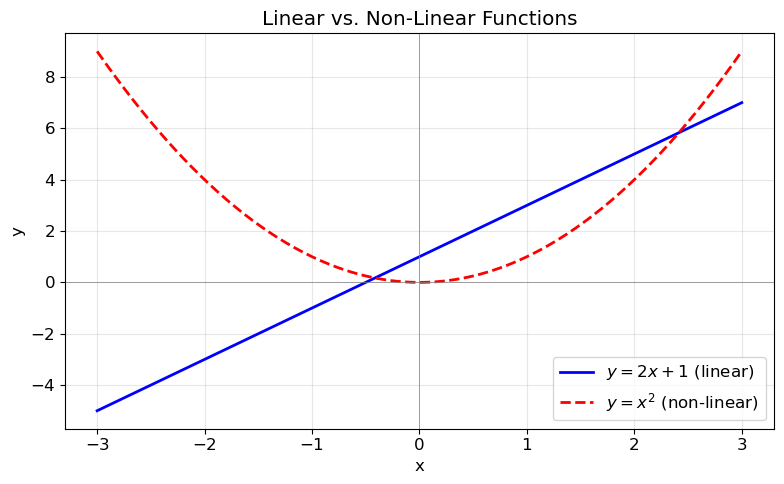

In [3]:
x = np.linspace(-3, 3, 300)
y_linear = 2 * x + 1        # Affine function (linear component: 2x)
y_nonlinear = x ** 2         # Non-linear (quadratic)

fig, ax = plt.subplots()
ax.plot(x, y_linear, color='blue', linewidth=2, label=r'$y = 2x + 1$ (linear)')
ax.plot(x, y_nonlinear, color='red', linewidth=2, linestyle='--', label=r'$y = x^2$ (non-linear)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear vs. Non-Linear Functions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** The linear function has a constant slope (rate of change = 2 everywhere), while the quadratic function's slope varies with $x$. At $x = 0$ the parabola is flat; at $x = 3$ the slope is 6. This variable rate of change is what we mean by "curvature" or non-linearity.

### Verifying Linearity Numerically

Let us check the additivity and homogeneity properties for both functions. A truly linear function $g(x) = 2x$ (no bias) should satisfy both. The affine function $f(x) = 2x + 1$ will fail additivity because of the bias, and $h(x) = x^2$ will fail both.

In [4]:
# Define three functions
g = lambda x: 2 * x          # Linear (through origin)
f = lambda x: 2 * x + 1      # Affine
h = lambda x: x ** 2          # Non-linear

x1, x2, c = 3.0, 5.0, 4.0

print("=== Additivity Check: f(x1 + x2) vs f(x1) + f(x2) ===")
for name, func in [('g(x)=2x', g), ('f(x)=2x+1', f), ('h(x)=x^2', h)]:
    lhs = func(x1 + x2)
    rhs = func(x1) + func(x2)
    print(f"  {name:12s}:  f({x1}+{x2}) = {lhs:6.1f},  f({x1})+f({x2}) = {rhs:6.1f}  =>  {'PASS' if np.isclose(lhs, rhs) else 'FAIL'}")

print("\n=== Homogeneity Check: f(c*x1) vs c*f(x1) ===")
for name, func in [('g(x)=2x', g), ('f(x)=2x+1', f), ('h(x)=x^2', h)]:
    lhs = func(c * x1)
    rhs = c * func(x1)
    print(f"  {name:12s}:  f({c}*{x1}) = {lhs:6.1f},  {c}*f({x1}) = {rhs:6.1f}  =>  {'PASS' if np.isclose(lhs, rhs) else 'FAIL'}")

=== Additivity Check: f(x1 + x2) vs f(x1) + f(x2) ===
  g(x)=2x     :  f(3.0+5.0) =   16.0,  f(3.0)+f(5.0) =   16.0  =>  PASS
  f(x)=2x+1   :  f(3.0+5.0) =   17.0,  f(3.0)+f(5.0) =   18.0  =>  FAIL
  h(x)=x^2    :  f(3.0+5.0) =   64.0,  f(3.0)+f(5.0) =   34.0  =>  FAIL

=== Homogeneity Check: f(c*x1) vs c*f(x1) ===
  g(x)=2x     :  f(4.0*3.0) =   24.0,  4.0*f(3.0) =   24.0  =>  PASS
  f(x)=2x+1   :  f(4.0*3.0) =   25.0,  4.0*f(3.0) =   28.0  =>  FAIL
  h(x)=x^2    :  f(4.0*3.0) =  144.0,  4.0*f(3.0) =   36.0  =>  FAIL


Only $g(x) = 2x$ passes both tests. The affine function $f(x) = 2x + 1$ fails because the bias term $b = 1$ gets duplicated under addition. This is a subtle but important distinction: neural network layers are affine maps, but we analyze their weight matrices using the tools of linear algebra.

## 1.3 Why Linear Algebra Matters in ML

This section walks through the five key roles of linear algebra in ML that the chapter identifies, each with a small code demonstration.

### 1.3.1 Data Representation: Vectors and Matrices

In ML, a single data point is a vector in $\mathbb{R}^n$, and a dataset of $m$ samples is an $m \times n$ matrix. This representation is not merely a convention; it is what makes vectorized computation (and GPU acceleration) possible.

In [5]:
# A single data point: 4 features (e.g., sepal length, sepal width, petal length, petal width)
x_sample = np.array([5.1, 3.5, 1.4, 0.2])
print(f"Single sample (vector in R^4): {x_sample}")
print(f"Shape: {x_sample.shape}")

# A dataset: 5 samples, each with 4 features
X = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [4.9, 3.0, 1.4, 0.2],
    [7.0, 3.2, 4.7, 1.4],
    [6.3, 3.3, 6.0, 2.5],
    [5.8, 2.7, 5.1, 1.9]
])
print(f"\nDataset matrix (5 samples x 4 features):\n{X}")
print(f"Shape: {X.shape}")

Single sample (vector in R^4): [5.1 3.5 1.4 0.2]
Shape: (4,)

Dataset matrix (5 samples x 4 features):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.3 3.3 6.  2.5]
 [5.8 2.7 5.1 1.9]]
Shape: (5, 4)


### 1.3.2 Model Training: Matrix Operations in Neural Networks

A single layer of a neural network computes $\mathbf{z} = W\mathbf{x} + \mathbf{b}$, followed by a non-linear activation. The forward pass is fundamentally a sequence of matrix-vector multiplications.

In [6]:
# Simulate one layer: 4 inputs -> 3 outputs
np.random.seed(42)
W = np.random.randn(3, 4)   # Weight matrix (3 x 4)
b = np.random.randn(3)      # Bias vector (3,)
x_input = np.array([5.1, 3.5, 1.4, 0.2])  # Input

# Forward pass (linear part)
z = W @ x_input + b
print(f"Weight matrix W (3x4):\n{W}\n")
print(f"Input x:  {x_input}")
print(f"Bias b:   {b}")
print(f"Linear output z = Wx + b: {z}")

# Apply ReLU activation (non-linear part)
a = np.maximum(0, z)
print(f"After ReLU activation:    {a}")

Weight matrix W (3x4):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Input x:  [5.1 3.5 1.4 0.2]
Bias b:   [ 0.24196227 -1.91328024 -1.72491783]
Linear output z = Wx + b: [ 3.50264932 -1.56255692 -2.96220777]
After ReLU activation:    [3.50264932 0.         0.        ]


### 1.3.3 Dimensionality Reduction: A PCA Preview

Principal Component Analysis projects data onto directions of maximum variance, found via eigenvalue decomposition. Here is a quick preview; full treatment comes in later chapters.

C:\Users\user\AppData\Local\Temp\ipykernel_42144\4033026590.py:6: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  data = np.random.multivariate_normal(mean, cov, 200)


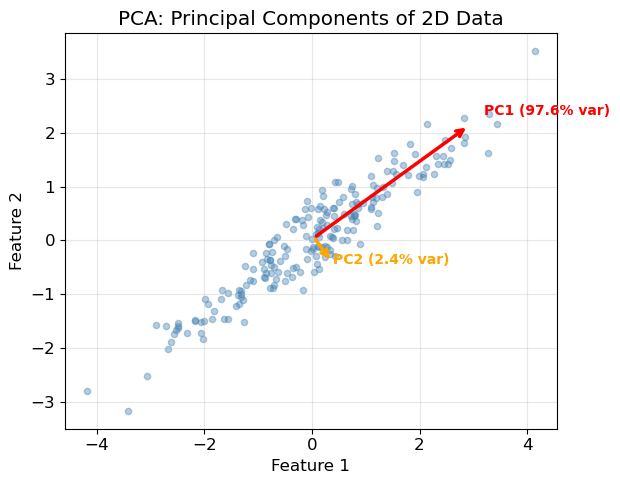

Explained variance ratio: [0.97624195 0.02375805]
PC1 alone captures 97.6% of the total variance.


In [7]:
# Generate synthetic 2D data with correlation
np.random.seed(7)
mean = [0, 0]
cov = [[2.0, 1.5],
       [1.5, 1.0]]
data = np.random.multivariate_normal(mean, cov, 200)

# Apply PCA to reduce to 1D
pca = PCA(n_components=2)
pca.fit(data)

# Visualization
fig, ax = plt.subplots()
ax.scatter(data[:, 0], data[:, 1], alpha=0.4, s=20, color='steelblue')

# Draw principal components as arrows
origin = pca.mean_
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    ax.annotate('', xy=origin + comp * np.sqrt(var) * 2,
                xytext=origin,
                arrowprops=dict(arrowstyle='->', color='red' if i == 0 else 'orange', lw=2.5))
    ax.text(*(origin + comp * np.sqrt(var) * 2.2),
            f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%} var)',
            fontsize=10, fontweight='bold',
            color='red' if i == 0 else 'orange')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('PCA: Principal Components of 2D Data')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"PC1 alone captures {pca.explained_variance_ratio_[0]:.1%} of the total variance.")

### 1.3.4 Optimization: Gradient Descent in Action

Gradient descent iteratively updates parameters by computing gradients (vector operations) and stepping in the direction that reduces the loss. Here we minimize a simple quadratic $f(x) = (x - 3)^2$ to build intuition.

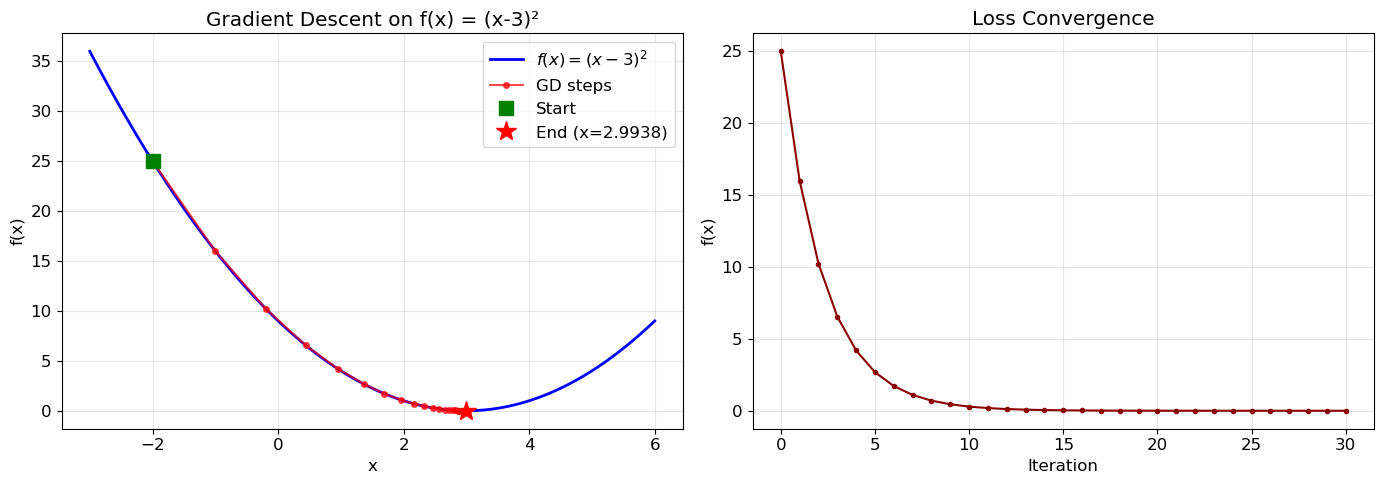

In [8]:
# Minimize f(x) = (x - 3)^2  =>  f'(x) = 2(x - 3)
def f(x):
    return (x - 3) ** 2

def grad_f(x):
    return 2 * (x - 3)

# Gradient descent
x_current = -2.0       # Starting point
lr = 0.1               # Learning rate
history = [x_current]

for step in range(30):
    x_current = x_current - lr * grad_f(x_current)
    history.append(x_current)

history = np.array(history)

# Visualization
x_plot = np.linspace(-3, 6, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: trajectory on the function
ax1.plot(x_plot, f(x_plot), 'b-', linewidth=2, label=r'$f(x) = (x-3)^2$')
ax1.plot(history, f(history), 'ro-', markersize=4, alpha=0.7, label='GD steps')
ax1.plot(history[0], f(history[0]), 'gs', markersize=10, label='Start')
ax1.plot(history[-1], f(history[-1]), 'r*', markersize=15, label=f'End (x={history[-1]:.4f})')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Gradient Descent on f(x) = (x-3)²')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: convergence plot
ax2.plot(f(history), 'o-', color='darkred', markersize=3)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('f(x)')
ax2.set_title('Loss Convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.3.5 Recommender Systems: Matrix Factorization Preview

A user-item rating matrix can be approximately decomposed as $R \approx UV^T$, where $U$ captures user preferences and $V$ captures item attributes in a low-dimensional latent space. Missing entries can then be predicted. This is a simplified illustration.

In [9]:
# User-item ratings (0 = missing/unknown)
R = np.array([
    [5, 3, 0, 1],
    [4, 0, 0, 1],
    [1, 1, 0, 5],
    [0, 0, 5, 4],
    [0, 1, 4, 0]
], dtype=float)

print("Original rating matrix (0 = unknown):")
print(R)

# Use truncated SVD for low-rank approximation (rank 2)
from numpy.linalg import svd
U_full, sigma, Vt_full = svd(R, full_matrices=False)

k = 2  # Latent factors
U_k = U_full[:, :k]
S_k = np.diag(sigma[:k])
Vt_k = Vt_full[:k, :]

R_approx = U_k @ S_k @ Vt_k

print(f"\nRank-{k} approximation (predicted ratings):")
print(np.round(R_approx, 2))
print(f"\nPredicted rating for User 1, Item 2 (was unknown): {R_approx[0, 2]:.2f}")
print(f"Predicted rating for User 3, Item 0 (was unknown): {R_approx[3, 0]:.2f}")

Original rating matrix (0 = unknown):
[[5. 3. 0. 1.]
 [4. 0. 0. 1.]
 [1. 1. 0. 5.]
 [0. 0. 5. 4.]
 [0. 1. 4. 0.]]

Rank-2 approximation (predicted ratings):
[[ 4.92  1.99 -0.72  1.96]
 [ 3.27  1.32 -0.43  1.34]
 [ 2.13  1.1   1.92  2.77]
 [-0.23  0.43  4.87  4.1 ]
 [-0.57  0.03  2.49  1.86]]

Predicted rating for User 1, Item 2 (was unknown): -0.72
Predicted rating for User 3, Item 0 (was unknown): -0.23


## 1.4 Python Tools for Linear Algebra

This section provides quick demonstrations of each core library so you can see what they offer. Detailed usage appears in later chapters.

### 1.4.1 NumPy: The Foundation

NumPy provides n-dimensional arrays and a comprehensive suite of linear algebra operations through `np.linalg`.

In [10]:
# Vector and matrix basics
v = np.array([1, 2, 3])
A = np.array([[1, 2], [3, 4], [5, 6]])

print(f"Vector v: {v}, shape: {v.shape}")
print(f"Matrix A:\n{A}\nShape: {A.shape}")

# Key operations
print(f"\nDot product v . v = {np.dot(v, v)}")
print(f"Norm of v = {np.linalg.norm(v):.4f}")

B = np.array([[1, 2, 3], [4, 5, 6]])
print(f"\nA @ B (matrix multiplication):\n{A @ B}")

# Eigenvalue decomposition of a square matrix
M = np.array([[4, 2], [1, 3]])
eigenvalues, eigenvectors = np.linalg.eig(M)
print(f"\nMatrix M:\n{M}")
print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")

Vector v: [1 2 3], shape: (3,)
Matrix A:
[[1 2]
 [3 4]
 [5 6]]
Shape: (3, 2)

Dot product v . v = 14
Norm of v = 3.7417

A @ B (matrix multiplication):
[[ 9 12 15]
 [19 26 33]
 [29 40 51]]

Matrix M:
[[4 2]
 [1 3]]
Eigenvalues: [5. 2.]
Eigenvectors:
[[ 0.89442719 -0.70710678]
 [ 0.4472136   0.70710678]]


### 1.4.2 SciPy: Advanced Linear Algebra

SciPy extends NumPy with specialized routines, including sparse matrix support and more linear algebra decompositions.

In [11]:
from scipy import linalg as sla
from scipy.sparse import csr_matrix

# LU decomposition
A = np.array([[2, 5, 8], [4, 6, 7], [3, 1, 2]], dtype=float)
P, L, U = sla.lu(A)
print("LU Decomposition of A:")
print(f"P (permutation):\n{P}")
print(f"L (lower triangular):\n{np.round(L, 4)}")
print(f"U (upper triangular):\n{np.round(U, 4)}")
print(f"Verify P @ L @ U = A: {np.allclose(P @ L @ U, A)}")

# Sparse matrix (common in large-scale ML)
print("\n--- Sparse Matrix ---")
dense = np.array([[1, 0, 0, 0], [0, 0, 3, 0], [0, 0, 0, 0], [0, 4, 0, 0]])
sparse = csr_matrix(dense)
print(f"Dense:\n{dense}")
print(f"Sparse representation:\n{sparse}")
print(f"Non-zero elements: {sparse.nnz} out of {dense.size} (sparsity: {1 - sparse.nnz/dense.size:.0%})")

LU Decomposition of A:
P (permutation):
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
L (lower triangular):
[[ 1.      0.      0.    ]
 [ 0.75    1.      0.    ]
 [ 0.5    -0.5714  1.    ]]
U (upper triangular):
[[ 4.      6.      7.    ]
 [ 0.     -3.5    -3.25  ]
 [ 0.      0.      2.6429]]
Verify P @ L @ U = A: True

--- Sparse Matrix ---
Dense:
[[1 0 0 0]
 [0 0 3 0]
 [0 0 0 0]
 [0 4 0 0]]
Sparse representation:
  (0, 0)	1
  (1, 2)	3
  (3, 1)	4
Non-zero elements: 3 out of 16 (sparsity: 81%)


### 1.4.3 SymPy: Symbolic Mathematics

SymPy performs exact symbolic computation, which is invaluable for verifying derivations and understanding structure before moving to numerical code.

In [12]:
import sympy as sp

# Symbolic matrix operations
M = sp.Matrix([[4, 2], [1, 3]])
print("Symbolic matrix M:")
sp.pprint(M)

print(f"\nDeterminant: {M.det()}")
print(f"Inverse:")
sp.pprint(M.inv())

print(f"\nEigenvalues: {M.eigenvals()}")
print(f"Eigenvectors:")
for eigenval, multiplicity, eigenvecs in M.eigenvects():
    print(f"  lambda = {eigenval}, eigenvector:", eigenvecs)

# Symbolic differentiation (relevant to optimization)
x = sp.Symbol('x')
f = x**3 - 6*x**2 + 9*x + 1
f_prime = sp.diff(f, x)
print(f"\nf(x) = {f}")
print(f"f'(x) = {f_prime}")
print(f"Critical points: {sp.solve(f_prime, x)}")

Symbolic matrix M:
⎡4  2⎤
⎢    ⎥
⎣1  3⎦

Determinant: 10
Inverse:
⎡3/10   -1/5⎤
⎢           ⎥
⎣-1/10  2/5 ⎦

Eigenvalues: {5: 1, 2: 1}
Eigenvectors:
  lambda = 2, eigenvector: [Matrix([
[-1],
[ 1]])]
  lambda = 5, eigenvector: [Matrix([
[2],
[1]])]

f(x) = x**3 - 6*x**2 + 9*x + 1
f'(x) = 3*x**2 - 12*x + 9
Critical points: [1, 3]


### 1.4.4 Matplotlib: Visualization

Geometric intuition is central to understanding linear algebra. Matplotlib lets us visualize vectors, transformations, and data structures.

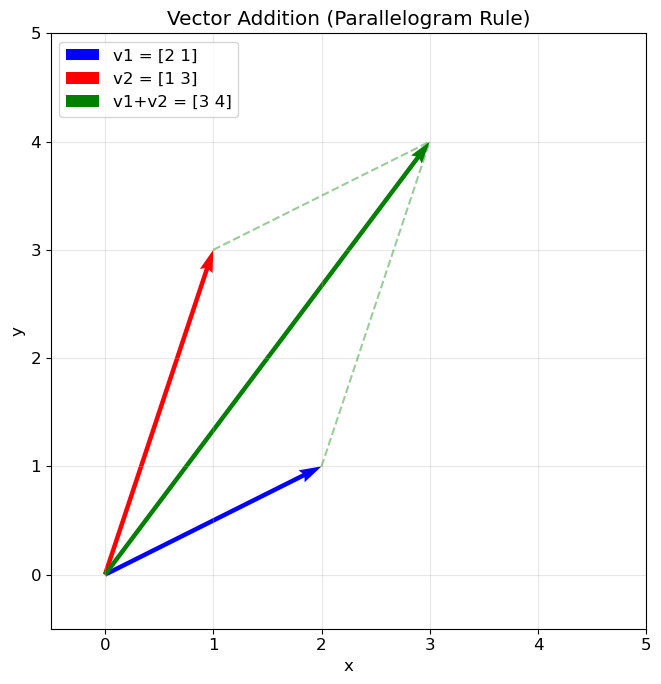

In [13]:
# Visualize 2D vectors and their sum
v1 = np.array([2, 1])
v2 = np.array([1, 3])
v_sum = v1 + v2

fig, ax = plt.subplots(figsize=(7, 7))
origin = np.array([0, 0])

ax.quiver(*origin, *v1, angles='xy', scale_units='xy', scale=1, color='blue', linewidth=2, label=f'v1 = {v1}')
ax.quiver(*origin, *v2, angles='xy', scale_units='xy', scale=1, color='red', linewidth=2, label=f'v2 = {v2}')
ax.quiver(*origin, *v_sum, angles='xy', scale_units='xy', scale=1, color='green', linewidth=2, label=f'v1+v2 = {v_sum}')

# Parallelogram rule (dashed lines)
ax.plot([v1[0], v_sum[0]], [v1[1], v_sum[1]], 'g--', alpha=0.4)
ax.plot([v2[0], v_sum[0]], [v2[1], v_sum[1]], 'g--', alpha=0.4)

ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Vector Addition (Parallelogram Rule)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4.5 Scikit-learn: ML Algorithms Built on Linear Algebra

Scikit-learn provides high-level implementations of algorithms whose internals rely heavily on linear algebra. Linear regression, for instance, solves a least-squares problem using matrix operations.

Learned weight (slope):  2.4385  (true: 2.5)
Learned bias (intercept): 2.9856  (true: 3.0)


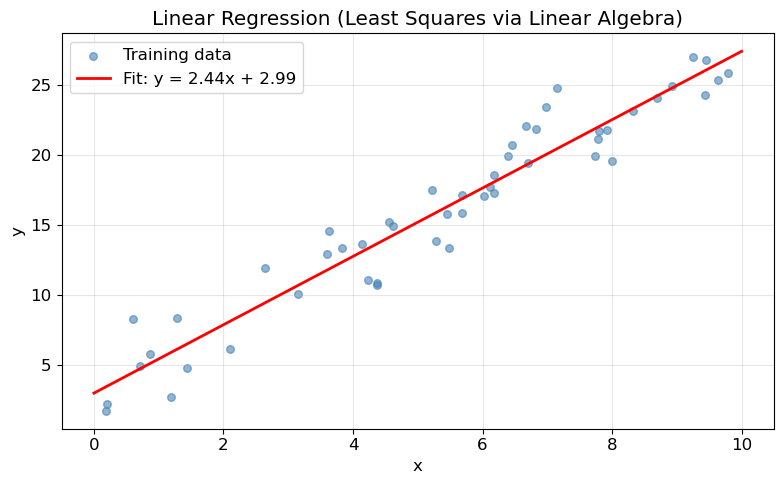

In [14]:
# Simple linear regression
np.random.seed(0)
X_train = np.random.rand(50, 1) * 10
y_train = 2.5 * X_train.squeeze() + 3 + np.random.randn(50) * 2  # y = 2.5x + 3 + noise

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Learned weight (slope):  {model.coef_[0]:.4f}  (true: 2.5)")
print(f"Learned bias (intercept): {model.intercept_:.4f}  (true: 3.0)")

# Plot
fig, ax = plt.subplots()
ax.scatter(X_train, y_train, alpha=0.6, s=30, color='steelblue', label='Training data')
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), 'r-', linewidth=2, label=f'Fit: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Regression (Least Squares via Linear Algebra)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.5 A Glimpse of Linear Transformations

A linear transformation maps vectors from one space to another via matrix multiplication. The geometric effect of a $2 \times 2$ matrix on the unit square is a powerful way to build intuition. Later chapters develop this fully; here is a preview.

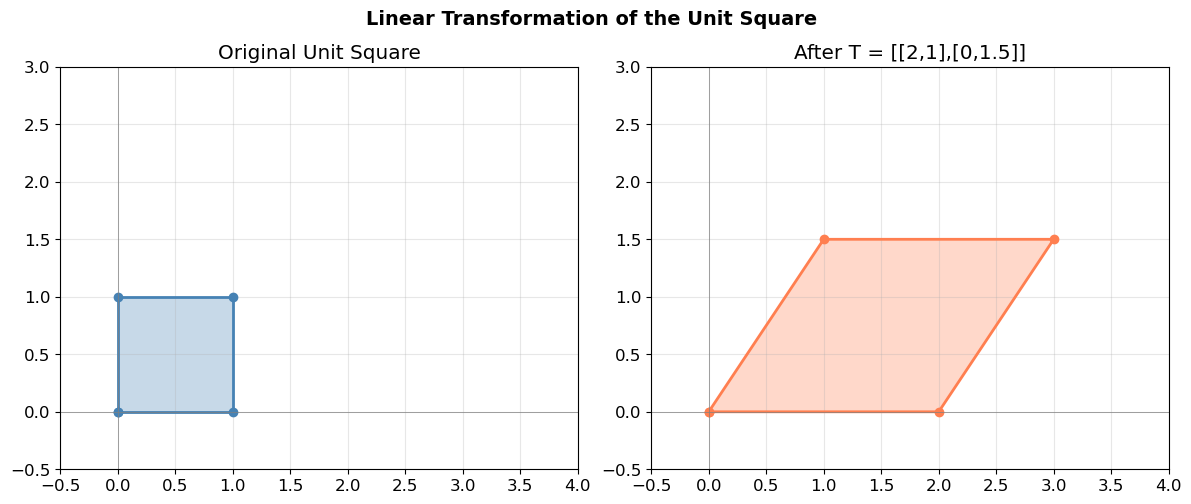

Determinant of T: 3.0
The area of the unit square (1.0) is scaled by |det(T)| = 3.0


In [15]:
# Define a transformation matrix
T = np.array([[2, 1],
              [0, 1.5]])

# Unit square vertices
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T

# Apply transformation
transformed = T @ square

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title, color in zip(axes,
                                   [square, transformed],
                                   ['Original Unit Square', f'After T = [[2,1],[0,1.5]]'],
                                   ['steelblue', 'coral']):
    ax.fill(data[0], data[1], alpha=0.3, color=color)
    ax.plot(data[0], data[1], 'o-', color=color, linewidth=2)
    ax.set_xlim(-0.5, 4)
    ax.set_ylim(-0.5, 3)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('Linear Transformation of the Unit Square', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Determinant of T: {np.linalg.det(T):.1f}")
print(f"The area of the unit square (1.0) is scaled by |det(T)| = {abs(np.linalg.det(T)):.1f}")

## 1.6 Chapter Roadmap: What Lies Ahead

The book progresses through the following topics, each building on the last:

| Chapter | Topic | ML Connection |
|---------|-------|---------------|
| 2 | Vectors | Feature representation, similarity measures |
| 3 | Matrices | Neural network weights, data transformations |
| 4 | Tensors | Images, video, multi-dimensional data |
| 5 | Linear Systems | Regression, model fitting |
| 6 | Linear Transformations | Data augmentation, projections |
| 7 | Determinants | Invertibility, volume scaling |
| 8 | Eigenvalues & Eigenvectors | PCA, stability analysis |
| 9 | Vector Spaces & Subspaces | Feature spaces, null spaces |
| 10 | Orthogonality | Decorrelation, least squares |
| 11 | Matrix Decompositions | SVD, QR, LU for dimensionality reduction |
| 12 | Optimization | Gradient descent, Hessians |
| 13 | Advanced Topics | Kernels, manifolds, numerical stability |

## 1.7 Exercises

The following exercises correspond to those at the end of Chapter 1. Try to solve them in the cells below.

**Exercise 1:** Explain why linear algebra is essential for ML, providing two specific examples from Section 1.1.

*Write your answer in this markdown cell by double-clicking to edit.*

**Exercise 2:** Plot the linear function $y = 3x - 1$ and the non-linear function $y = x^3$ on the same graph. Explain how their behaviors differ.

In [16]:
# Exercise 2: Your code here
x = np.linspace(-3, 3, 300)

# TODO: compute y_linear and y_nonlinear
# TODO: create the plot with labels, legend, and grid


**Exercise 3:** Identify three Python libraries from Section 1.4 and describe their roles in linear algebra for ML.

*Write your answer in this markdown cell.*

**Exercise 4:** Define what a vector and a matrix represent in the context of ML. Give one real-world example of each.

In [17]:
# Exercise 4: Demonstrate with code
# Create a vector representing a real-world data point (e.g., a house: [area, bedrooms, age, price])
# Create a matrix representing a small dataset of such data points

# TODO: Your code here


---

**Exercise Solutions**

Expand the cells below to see reference solutions.

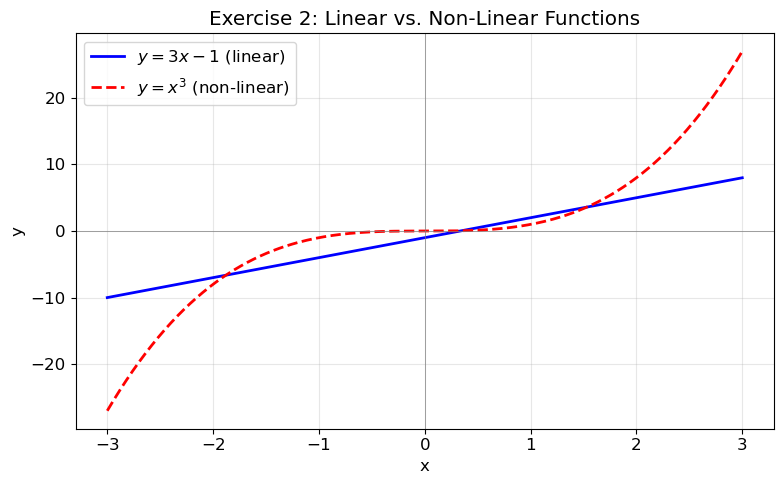

The linear function y = 3x - 1 has a constant slope of 3.
The cubic y = x^3 has slope 3x^2, which varies: flat at x=0, steep at |x|>1.
Unlike the quadratic, the cubic is odd-symmetric and spans all real y-values.


In [18]:
# --- Solution: Exercise 2 ---

x = np.linspace(-3, 3, 300)
y_linear = 3 * x - 1
y_nonlinear = x ** 3

fig, ax = plt.subplots()
ax.plot(x, y_linear, 'b-', linewidth=2, label=r'$y = 3x - 1$ (linear)')
ax.plot(x, y_nonlinear, 'r--', linewidth=2, label=r'$y = x^3$ (non-linear)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Exercise 2: Linear vs. Non-Linear Functions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The linear function y = 3x - 1 has a constant slope of 3.")
print("The cubic y = x^3 has slope 3x^2, which varies: flat at x=0, steep at |x|>1.")
print("Unlike the quadratic, the cubic is odd-symmetric and spans all real y-values.")

In [19]:
# --- Solution: Exercise 4 ---

# Vector: one house described by [area_sqft, bedrooms, age_years, price_usd]
house = np.array([1500, 3, 10, 350000])
print(f"Single house (vector in R^4): {house}")
print(f"Features: [area_sqft, bedrooms, age_years, price_usd]")

# Matrix: dataset of 4 houses
houses = np.array([
    [1500, 3, 10, 350000],
    [2200, 4,  5, 520000],
    [ 900, 2, 25, 180000],
    [3000, 5,  2, 750000]
])
print(f"\nHousing dataset (4 samples x 4 features):\n{houses}")
print(f"Shape: {houses.shape}")
print("\nRows = individual houses, Columns = features")

Single house (vector in R^4): [  1500      3     10 350000]
Features: [area_sqft, bedrooms, age_years, price_usd]

Housing dataset (4 samples x 4 features):
[[  1500      3     10 350000]
 [  2200      4      5 520000]
 [   900      2     25 180000]
 [  3000      5      2 750000]]
Shape: (4, 4)

Rows = individual houses, Columns = features
